In [ ]:
#An example of DT/Sklearn with the dataset breastcancer
# A modified version of the work found here
# http://eric.univ-lyon2.fr/~ricco/tanagra/fichiers/fr_Tanagra_Scikit_Learn_Decision_Tree.pdf

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import export_text
from sklearn import metrics

#Lecture des données

df = pd.read_csv('breast_cancer.csv')

print(df.Cls.value_counts())

print(df.Cls.value_counts(normalize=True))

Cls
1    357
0    212
Name: count, dtype: int64
Cls
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [2]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Cls
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
#dfTrain, dfTest = train_test_split(df,test_size=169,random_state=1,stratify=df.Cls)
dfTrain, dfTest = train_test_split(df,test_size=0.25,random_state=1,stratify=df.Cls)

print('##################"')
print(df.Cls.value_counts()/df.Cls.size)
print('##################"')
print(dfTrain.Cls.value_counts()/dfTrain.Cls.size)
print('##################"')
print(dfTest.Cls.size)
print('##################"')





##################"
Cls
1    0.627417
0    0.372583
Name: count, dtype: float64
##################"
Cls
1    0.626761
0    0.373239
Name: count, dtype: float64
##################"
143
##################"


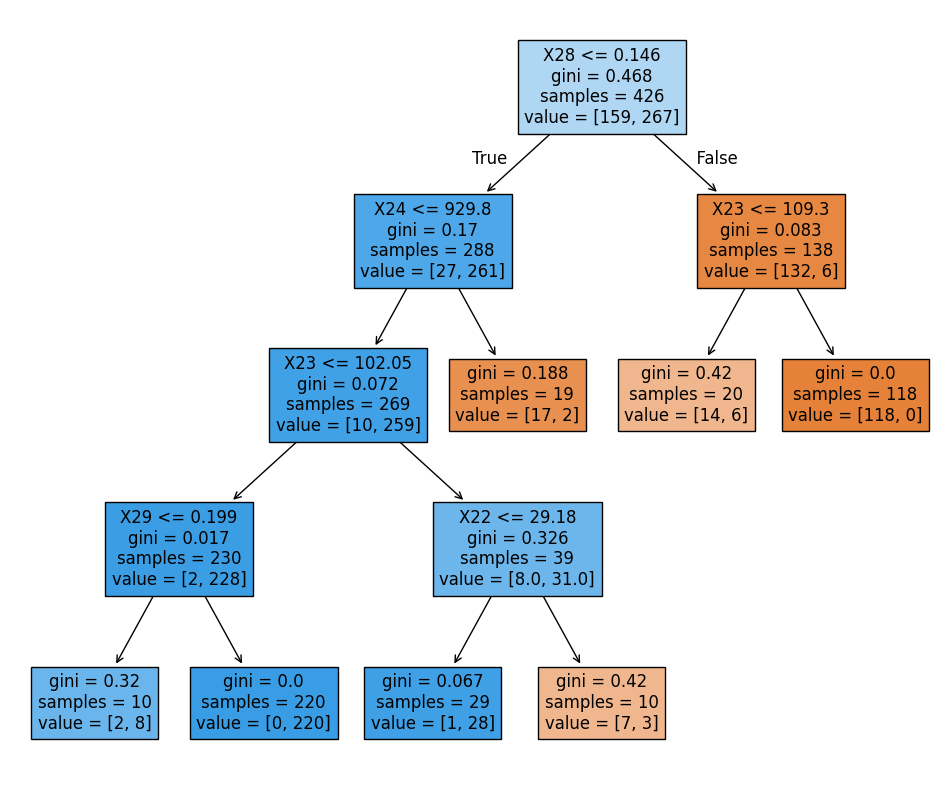

In [4]:
#instanciation de l'arbre
arbreFirst = DecisionTreeClassifier(min_samples_split=30,min_samples_leaf=10)

#construction de l'arbre
arbreFirst.fit(X = dfTrain.iloc[:,:-1], y = dfTrain.Cls)

#Affichage de l'arbre
plt.figure(figsize=(12,10))
plot_tree(arbreFirst,feature_names = list(df.columns[:-1]),filled=True)
plt.show()



In [5]:
#Affichage des règles
tree_rules = export_text(arbreFirst,feature_names = list(df.columns[:-1]),show_weights=True)
print(tree_rules)

#prédiction sur l'échantillon test
predFirst = arbreFirst.predict(X=dfTest.iloc[:,:-1])

#matrice de confusion
print(metrics.confusion_matrix(dfTest.Cls,predFirst))

#Affichage de la précision
print(metrics.accuracy_score(dfTest.Cls,predFirst))

|--- X28 <= 0.15
|   |--- X24 <= 929.80
|   |   |--- X23 <= 102.05
|   |   |   |--- X29 <= 0.20
|   |   |   |   |--- weights: [2.00, 8.00] class: 1
|   |   |   |--- X29 >  0.20
|   |   |   |   |--- weights: [0.00, 220.00] class: 1
|   |   |--- X23 >  102.05
|   |   |   |--- X22 <= 29.18
|   |   |   |   |--- weights: [1.00, 28.00] class: 1
|   |   |   |--- X22 >  29.18
|   |   |   |   |--- weights: [7.00, 3.00] class: 0
|   |--- X24 >  929.80
|   |   |--- weights: [17.00, 2.00] class: 0
|--- X28 >  0.15
|   |--- X23 <= 109.30
|   |   |--- weights: [14.00, 6.00] class: 0
|   |--- X23 >  109.30
|   |   |--- weights: [118.00, 0.00] class: 0

[[49  4]
 [ 7 83]]
0.9230769230769231
